#### Лабораторная работа 2 по дисциплине Методы Оптимизации. ####
#### Выполнили студенты групп _Р3222, Р3223_ - __Сафин Максим и Фокин Владимир__. ####

#### Исходные данные  ####
##### Исследуемая функция: $f(x) = 1.826 * (sin^3(x) + cos^2(x) - 0.5sin(2x))$
##### Промежуток: $[0, 8]$

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from fontTools.misc.bezierTools import epsilon

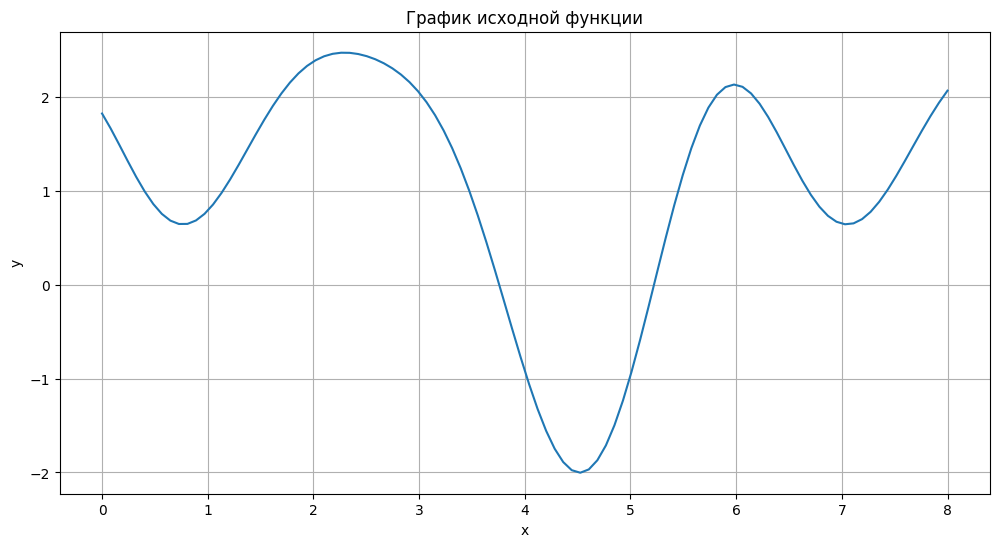

In [27]:
# График исходной функции
def f(x):
    return 1.826 * (np.sin(x) ** 3 + np.cos(x) ** 2 - 0.5 * np.sin(2*x))

a = 0
b = 8
x = np.linspace(a, b, 100)  # 100 точек от -10 до 10
y = 1.826 * (np.sin(x) ** 3 + np.cos(x) ** 2 - 0.5 * np.sin(2*x))

plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('График исходной функции')
plt.grid(True)
plt.show()

По графику можно заметить 5 точек экстремума:
1. На промежутке [0, 1] (минимум)
2. На промежутке [2, 3] (максимум)
3. На промежутке [4, 5] (максимум)
4. На промежутке [5, 7] (максимум)
5. На промежутке [6, 8] (максимум)

Погрешность $\epsilon$ = 0.0001

## Метод золотого сечения ##
На первом шаге (итерации) точки вычисляются по формулам:
$x1=a+0,382(b-a), x2=a+0,618(b-a)$

Затем вычисляются значение функции в этих точках.

Возможны два случая:

Если $f(x1) < f(x2)$, то оставляем отрезок $[a,x2 ]$. На второй итерации $x2$ полагаем равным $x1 $, а $x1$ вычисляем по формуле
$x1=a+0$,$382(x2-a)$. Значение функции вычисляется только в точке $x1$, так как значение функции в $x2$ уже было вычислено на предыдущем шаге.

Если $f(x1) ≥ f(x2)$, то оставляем отрезок $[x1,b ]$. На второй итерации $x1$ полагаем равным $x2$, а $x2$ вычисляем по формуле
$x2=a+0,618(b-x1)$. Значение функции вычисляется только в точке x2, так как значение функции в $x1$ уже было вычислено на предыдущем шаге.

Вычисления продолжают до тех пор, пока длина интервала не станет меньше требуемой точности.


In [87]:
def golden_slice(a, b, x1, x2, eps = 0.01):
    if ((b - a) < eps):
        return (a + b) / 2

    if (x1 == None and x2 == None):
        x1 = a + 0.382 * (b - a)
        x2 = a + 0.618 * (b - a)
    elif (x1 == None):
        x1 = a + 0.382 * (x2 - a)
    elif (x2 == None):
        x2 = a + 0.618 * (b - x1)

    y1 = f(x1)
    y2 = f(x2)

    # print(f'a = {a}, b = {b}, x1 = {x1}, x2 = {x2}, f1 = {y1}, f2 = {y2}')

    if (y1 < y2):
        return golden_slice(a, x2, None, x1)
    else:
        return golden_slice(x1, b, x2, None)

xMin = golden_slice(4, 5, None, None)

print(f'Точка минимума: {xMin:.6f}')
print(f'Значение функции в точке: {f(xMin):.6f}')


Точка минимума: 4.521286
Значение функции в точке: -2.002721
